##### 1. Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("data/sha_claims.csv", parse_dates=["claim_date"])

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", None)

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(25000, 29)
claim_id                             str
member_id                            str
claim_date                datetime64[us]
claim_status                         str
provider_id                          str
provider_name                        str
provider_type                        str
provider_county                      str
member_age                         int64
member_gender                        str
member_county                        str
member_risk_tier                     str
benefit_package                      str
claim_type                           str
diagnosis_code                       str
diagnosis_description                str
procedure_code                       str
procedure_description                str
drug_code                            str
drug_description                     str
admission_days                     int64
consultation_fee_kes             float64
procedure_cost_kes               float64
drug_cost_kes                    float64
lab_

##### 2. Univariate - Financial Distributions

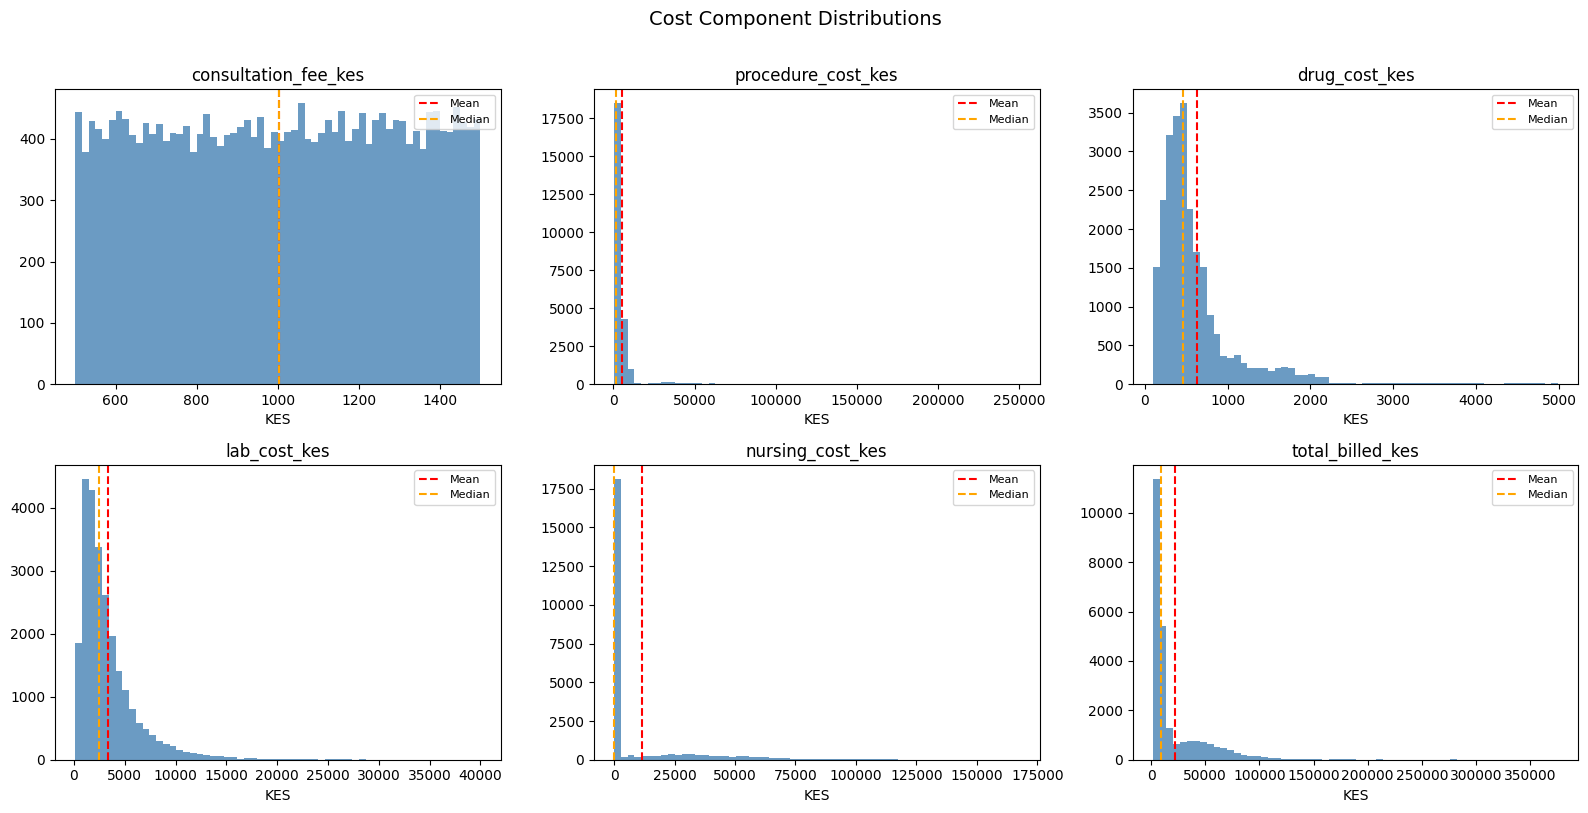

                         count      mean       std      min      25%      50%  \
consultation_fee_kes 25,000.00  1,002.31    289.82   500.00   750.38 1,004.32   
procedure_cost_kes   25,000.00  5,556.52 16,425.65   400.67 1,026.51 1,796.99   
drug_cost_kes        25,000.00    631.59    568.66   100.01   324.19   468.33   
lab_cost_kes         25,000.00  3,368.45  3,115.47   109.87 1,430.93 2,453.53   
nursing_cost_kes     25,000.00 11,402.71 23,372.63     0.00     0.00     0.00   
total_billed_kes     25,000.00 21,961.58 31,358.27 1,723.85 5,321.91 8,820.98   

                           75%        max  skew  
consultation_fee_kes  1,254.22   1,499.91 -0.01  
procedure_cost_kes    4,823.99 249,954.49  9.00  
drug_cost_kes           698.81   4,990.39  3.33  
lab_cost_kes          4,192.60  40,000.00  3.09  
nursing_cost_kes     10,698.23 167,497.51  2.45  
total_billed_kes     26,971.50 375,895.56  3.82  


In [2]:
cost_cols = ["consultation_fee_kes", "procedure_cost_kes",
             "drug_cost_kes", "lab_cost_kes",
             "nursing_cost_kes", "total_billed_kes"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cost_cols):
    axes[i].hist(df[col], bins=60, edgecolor="none", color="steelblue", alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel("KES")
    axes[i].axvline(df[col].mean(),   color="red",    linestyle="--", label="Mean")
    axes[i].axvline(df[col].median(), color="orange", linestyle="--", label="Median")
    axes[i].legend(fontsize=8)

plt.suptitle("Cost Component Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Summary stats + skewness
print(df[cost_cols].describe().T.assign(skew=df[cost_cols].skew()))

##### Interpretations

_consultation_fee_kes_
###### The distribution is almost perfectly flat across KES 500–1,500, with the mean very close to the median and a skew of -0.01. This column appears clean, meaning it has low FWA risk. Under SHA, outpatient consultations are paid against prescribed maximum tariffs, which constrains but does not fully eliminate room for inflation or balance‑billing outside the scheme.

_procedure_cost_kes_
###### A skew of 9.00 is the most extreme in the dataset. The median is KES 1,797, while the mean is KES 5,557, pulled upward by a long right tail extending to KES 249,954. The bulk of claims cluster below KES 10,000, but the histogram shows a thick right tail. This should be a primary FWA signal column, since procedure cost is often the easiest component to inflate (via upcoding, phantom procedures, or unbundling). The gap between the median and maximum is over 100×, which warrants close provider‑level scrutiny.

_drug_cost_kes_
###### Right‑skewed at 3.33, with a median of KES 468 and a mean of KES 632. The bulk of claims sit below KES 1,000, which is consistent with generic drug dispensing under SHA. The tail up to KES 4,990 likely reflects higher‑cost drugs such as insulin; these should be checked for clinical consistency against the diagnosis codes on the same row (for example, insulin billed against a malaria diagnosis would be a red flag).

_lab_cost_kes_
###### Skew of 3.09, median KES 2,454 versus mean KES 3,368, with a hard cap visible at KES 40,000. The right tail is notable but less extreme than for procedure costs. Lab costs are commonly abused through phantom tests, such as billing for a comprehensive metabolic panel on a routine URTI visit; cross‑referencing with diagnosis_code helps validate clinical necessity.

_nursing_cost_kes_
###### The median and 25th percentile are both KES 0.00, which is expected because outpatient claims (72% of the dataset) should typically have zero nursing cost. The mean of KES 11,403 is driven entirely by inpatient rows. The histogram’s massive spike at zero followed by a spread up to KES 167,498 reflects this two‑population structure. The integrity check here is critical: any row where nursing_cost_kes > 0 and admission_days == 0 is a strong billing‑fraud signal, since nursing care is being charged without an admitted patient.

_total_billed_kes_
###### Skew of 3.82, with a median of KES 8,821 versus a mean of KES 21,962, so the mean is about 2.5× the median. This is the most important high level signal because it indicates that a relatively small number of high value claims are pulling the average up sharply. The tail extending to KES 375,896 on what should mostly be routine SHA claims is significant. In practice, SHA would expect most claims to sit within a diagnosis specific cost band, so any claim exceeding roughly 3× the band median for its diagnosis should be queued for automatic review.

###### Takeaway
###### Procedure cost is driving the bulk of total bill inflation. Procedure_cost_kes should be the primary stratification variable in provider profiling, rather than total_billed_kes. A provider can keep total bills moderate while systematically overbilling on procedures; that pattern is hidden in the aggregate but becomes visible when this component is isolated.